In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------

df = pd.read_csv(
    "students_2022.csv",
    low_memory=False
)

print("Dataset shape:", df.shape)

# ---------------------------------------------------------
# 2. Create the correct dropout target
# A = dropout
# B = non-dropout
# ---------------------------------------------------------

df = df[df["abandono_hash"].isin(["A", "B"])].copy()

df["dropout"] = df["abandono_hash"].map({
    "A": 1,
    "B": 0
})

print("\nTarget distribution:")
print(df["dropout"].value_counts())

print(
    "\nOverall dropout rate:",
    round(df["dropout"].mean() * 100, 2),
    "%"
)

# ---------------------------------------------------------
# 3. Define all digital activity groups
# ---------------------------------------------------------

digital_groups = {
    "pft_events":
        "Number of LMS events performed by the student",

    "pft_visits":
        "Number of visits to the course LMS",

    "pft_days_logged":
        "Number of days the student accessed the LMS",

    "pft_assignment_submissions":
        "Number of assignments submitted through the LMS",

    "pft_test_submissions":
        "Number of tests or exams submitted through the LMS",

    "pft_total_minutes":
        "Total number of minutes spent logged into the LMS",

    "resource_events":
        "Number of actions performed in the LMS resources section",

    "n_resource_days":
        "Number of days the resources section was accessed",

    "n_wifi_days":
        "Number of days the university Wi-Fi was accessed"
}

# ---------------------------------------------------------
# 4. Automatically collect the monthly columns
# ---------------------------------------------------------

group_columns = {}

for group_name in digital_groups:

    columns = [
        column for column in df.columns
        if column.startswith(group_name + "_20")
    ]

    # Sort columns chronologically
    columns = sorted(
        columns,
        key=lambda column: (
            int(column.rsplit("_", 2)[-2]),
            int(column.rsplit("_", 1)[-1])
        )
    )

    group_columns[group_name] = columns

    print(
        group_name,
        "contains",
        len(columns),
        "monthly columns"
    )

Dataset shape: (20427, 170)

Target distribution:
dropout
0    18933
1     1494
Name: count, dtype: int64

Overall dropout rate: 7.31 %
pft_events contains 11 monthly columns
pft_visits contains 11 monthly columns
pft_days_logged contains 11 monthly columns
pft_assignment_submissions contains 11 monthly columns
pft_test_submissions contains 11 monthly columns
pft_total_minutes contains 11 monthly columns
resource_events contains 11 monthly columns
n_resource_days contains 11 monthly columns
n_wifi_days contains 11 monthly columns


Part 1: Create annual totals

In [3]:
# ---------------------------------------------------------
# 5. Create annual totals for every digital attribute
# ---------------------------------------------------------

for group_name, columns in group_columns.items():

    if len(columns) == 0:
        print("No columns found for:", group_name)
        continue

    df[group_name + "_total"] = df[columns].sum(axis=1)

    df[group_name + "_monthly_mean"] = df[columns].mean(axis=1)

    # Number of months in which the student had activity
    df[group_name + "_active_months"] = (
        df[columns] > 0
    ).sum(axis=1)

Part 2: Compare dropout and non-dropout students

In [4]:
# ---------------------------------------------------------
# 6. Compare annual activity between the two groups
# ---------------------------------------------------------

annual_results = []

for group_name in digital_groups:

    total_column = group_name + "_total"

    if total_column not in df.columns:
        continue

    dropout_students = df.loc[
        df["dropout"] == 1,
        total_column
    ]

    non_dropout_students = df.loc[
        df["dropout"] == 0,
        total_column
    ]

    dropout_mean = dropout_students.mean()
    non_dropout_mean = non_dropout_students.mean()

    dropout_median = dropout_students.median()
    non_dropout_median = non_dropout_students.median()

    correlation = df[
        [total_column, "dropout"]
    ].corr().iloc[0, 1]

    if non_dropout_mean != 0:

        percentage_difference = (
            (dropout_mean - non_dropout_mean)
            / non_dropout_mean
        ) * 100

    else:
        percentage_difference = np.nan

    annual_results.append({
        "attribute": group_name,
        "description": digital_groups[group_name],
        "dropout_mean": dropout_mean,
        "non_dropout_mean": non_dropout_mean,
        "dropout_median": dropout_median,
        "non_dropout_median": non_dropout_median,
        "percentage_difference": percentage_difference,
        "correlation_with_dropout": correlation
    })

annual_summary = pd.DataFrame(annual_results)

annual_summary = annual_summary.sort_values(
    "correlation_with_dropout"
)

print("\nAnnual digital activity analysis:")

print(
    annual_summary[
        [
            "attribute",
            "dropout_mean",
            "non_dropout_mean",
            "percentage_difference",
            "correlation_with_dropout"
        ]
    ].round(3)
)


Annual digital activity analysis:
                    attribute  dropout_mean  non_dropout_mean  \
6             resource_events       265.571           489.085   
5           pft_total_minutes      8114.239         14594.368   
7             n_resource_days        76.727           128.085   
1                  pft_visits       197.594           349.424   
2             pft_days_logged       117.284           192.015   
0                  pft_events       943.611          1606.732   
8                 n_wifi_days       450.898           659.540   
3  pft_assignment_submissions         7.986            12.170   
4        pft_test_submissions        10.521            14.427   

   percentage_difference  correlation_with_dropout  
6                -45.701                    -0.110  
5                -44.402                    -0.103  
7                -40.097                    -0.102  
1                -43.451                    -0.099  
2                -38.919                    -0.09

Part 3: Annual comparison graph

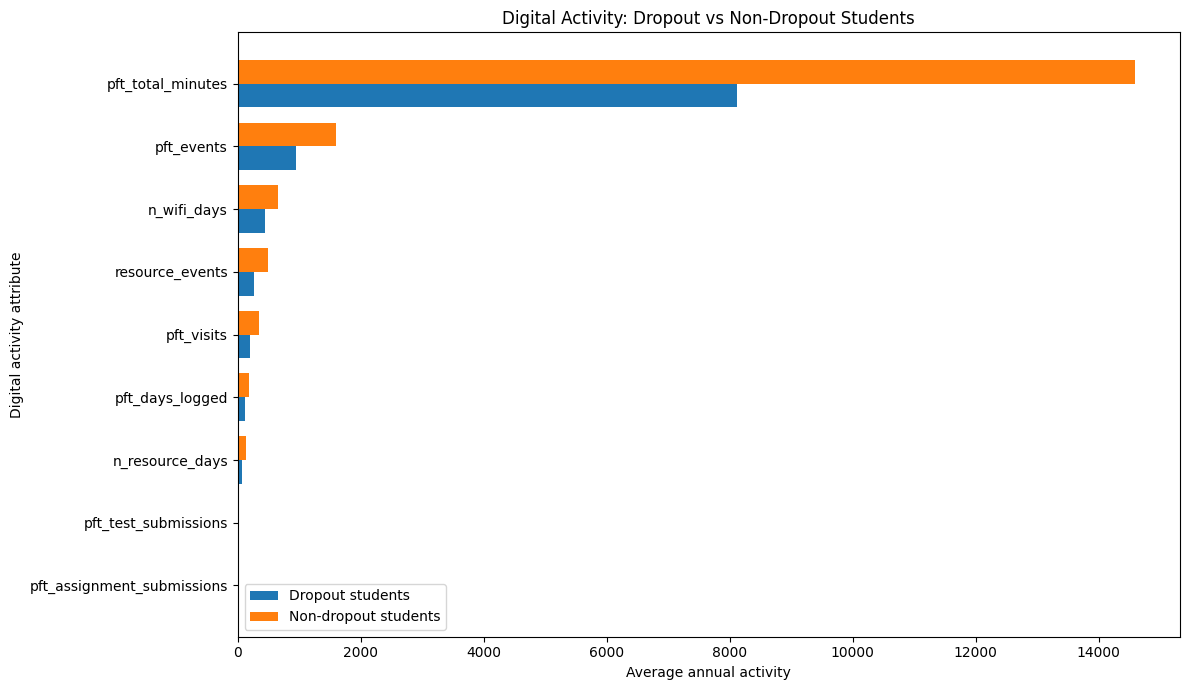

In [5]:
# ---------------------------------------------------------
# 7. Plot dropout versus non-dropout annual averages
# ---------------------------------------------------------

plot_data = annual_summary.sort_values(
    "non_dropout_mean"
).copy()

positions = np.arange(len(plot_data))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    positions - bar_width / 2,
    plot_data["dropout_mean"],
    height=bar_width,
    label="Dropout students"
)

ax.barh(
    positions + bar_width / 2,
    plot_data["non_dropout_mean"],
    height=bar_width,
    label="Non-dropout students"
)

ax.set_yticks(positions)

ax.set_yticklabels(
    plot_data["attribute"]
)

ax.set_xlabel("Average annual activity")

ax.set_ylabel("Digital activity attribute")

ax.set_title(
    "Digital Activity: Dropout vs Non-Dropout Students"
)

ax.legend()

plt.tight_layout()
plt.show()

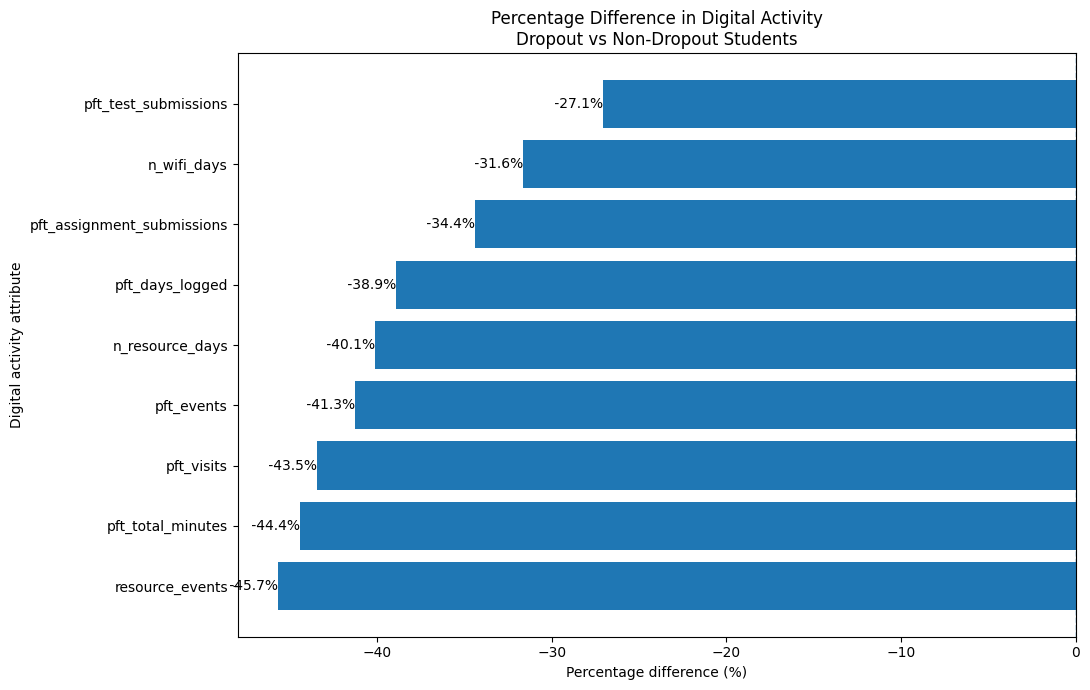

In [6]:
import matplotlib.pyplot as plt

plot_data = annual_summary.sort_values(
    "percentage_difference"
).copy()

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    plot_data["attribute"],
    plot_data["percentage_difference"]
)

ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Percentage Difference in Digital Activity\n"
    "Dropout vs Non-Dropout Students"
)

ax.set_xlabel(
    "Percentage difference (%)"
)

ax.set_ylabel(
    "Digital activity attribute"
)

for bar, value in zip(
    bars,
    plot_data["percentage_difference"]
):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f}%",
        va="center",
        ha="right" if value < 0 else "left"
    )

plt.tight_layout()
plt.show()

Part 4: Analyse every month separately

In [12]:
# ---------------------------------------------------------
# 8. Monthly analysis for all columns
# ---------------------------------------------------------

monthly_results = []

for group_name, columns in group_columns.items():

    for column in columns:

        parts = column.rsplit("_", 2)

        year = int(parts[-2])
        month = int(parts[-1])

        dropout_mean = df.loc[
            df["dropout"] == 1,
            column
        ].mean()

        non_dropout_mean = df.loc[
            df["dropout"] == 0,
            column
        ].mean()

        correlation = df[
            [column, "dropout"]
        ].corr().iloc[0, 1]

        monthly_results.append({
            "attribute": group_name,
            "column": column,
            "year": year,
            "month": month,
            "date": pd.Timestamp(
                year=year,
                month=month,
                day=1
            ),
            "dropout_mean": dropout_mean,
            "non_dropout_mean": non_dropout_mean,
            "correlation_with_dropout": correlation
        })

monthly_summary = pd.DataFrame(monthly_results)

monthly_summary = monthly_summary.sort_values(
    ["attribute", "date"]
)

print("\nMonthly analysis:")
print(monthly_summary.round(3))


Monthly analysis:
          attribute                   column  year  month       date  \
77  n_resource_days   n_resource_days_2022_9  2022      9 2022-09-01   
78  n_resource_days  n_resource_days_2022_10  2022     10 2022-10-01   
79  n_resource_days  n_resource_days_2022_11  2022     11 2022-11-01   
80  n_resource_days  n_resource_days_2022_12  2022     12 2022-12-01   
81  n_resource_days   n_resource_days_2023_1  2023      1 2023-01-01   
..              ...                      ...   ...    ...        ...   
72  resource_events   resource_events_2023_3  2023      3 2023-03-01   
73  resource_events   resource_events_2023_4  2023      4 2023-04-01   
74  resource_events   resource_events_2023_5  2023      5 2023-05-01   
75  resource_events   resource_events_2023_6  2023      6 2023-06-01   
76  resource_events   resource_events_2023_7  2023      7 2023-07-01   

    dropout_mean  non_dropout_mean  correlation_with_dropout  
77         7.272            10.135                   

Part 5: Identify the most important month

In [8]:
# ---------------------------------------------------------
# 9. Find the month with the strongest dropout relationship
# ---------------------------------------------------------

strongest_months = (
    monthly_summary
    .loc[
        monthly_summary
        .groupby("attribute")[
            "correlation_with_dropout"
        ]
        .idxmin()
    ]
    .sort_values("correlation_with_dropout")
)

print(
    strongest_months[
        [
            "attribute",
            "date",
            "column",
            "dropout_mean",
            "non_dropout_mean",
            "correlation_with_dropout"
        ]
    ].round(3)
)

                     attribute       date                              column  \
64           pft_total_minutes 2023-06-01            pft_total_minutes_2023_6   
30             pft_days_logged 2023-05-01              pft_days_logged_2023_5   
85             n_resource_days 2023-05-01              n_resource_days_2023_5   
73             resource_events 2023-04-01              resource_events_2023_4   
19                  pft_visits 2023-05-01                   pft_visits_2023_5   
3                   pft_events 2022-12-01                  pft_events_2022_12   
52        pft_test_submissions 2023-05-01         pft_test_submissions_2023_5   
96                 n_wifi_days 2023-05-01                  n_wifi_days_2023_5   
36  pft_assignment_submissions 2022-12-01  pft_assignment_submissions_2022_12   

    dropout_mean  non_dropout_mean  correlation_with_dropout  
64       637.020          1471.556                    -0.104  
30        11.183            21.590                    -0.104  


Part 6: Monthly graph for all nine attributes

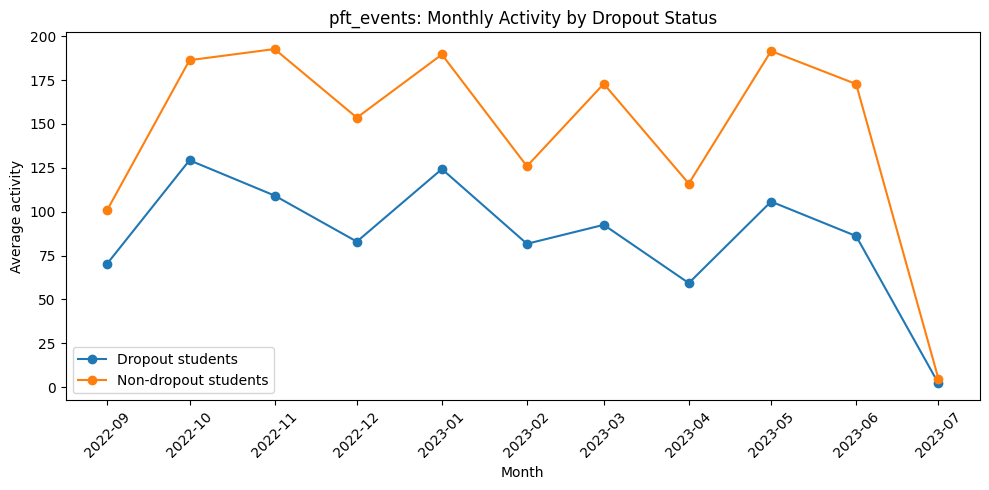

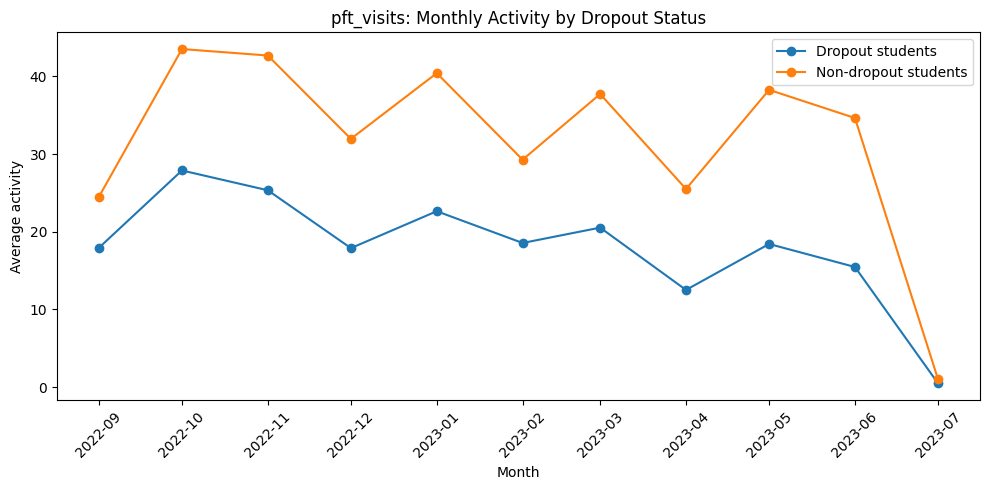

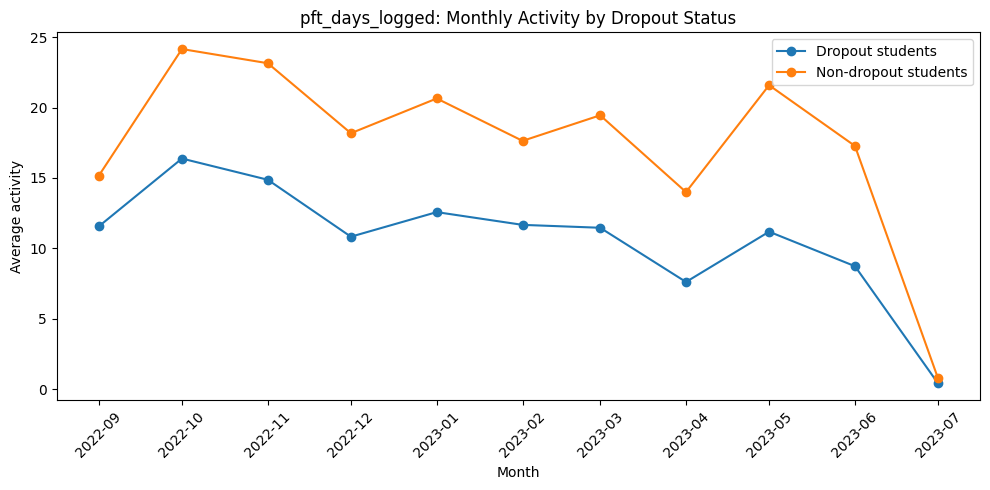

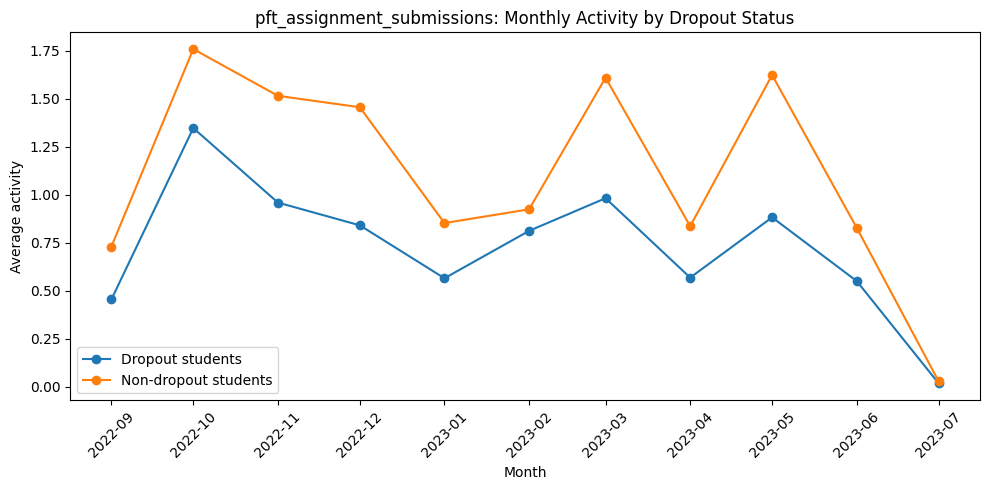

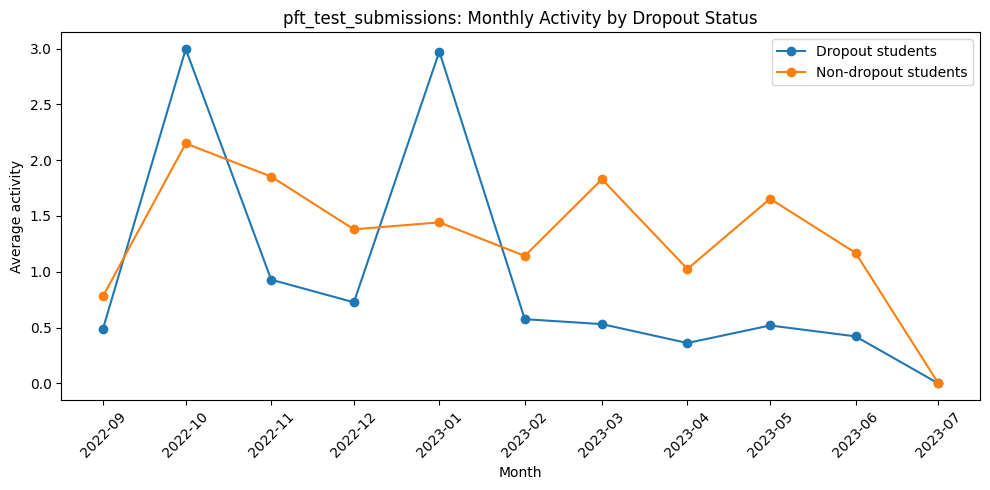

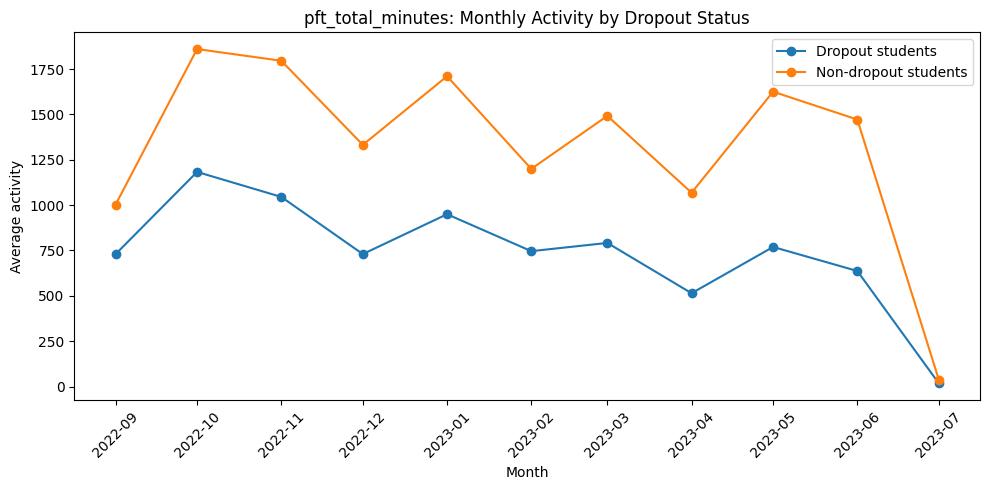

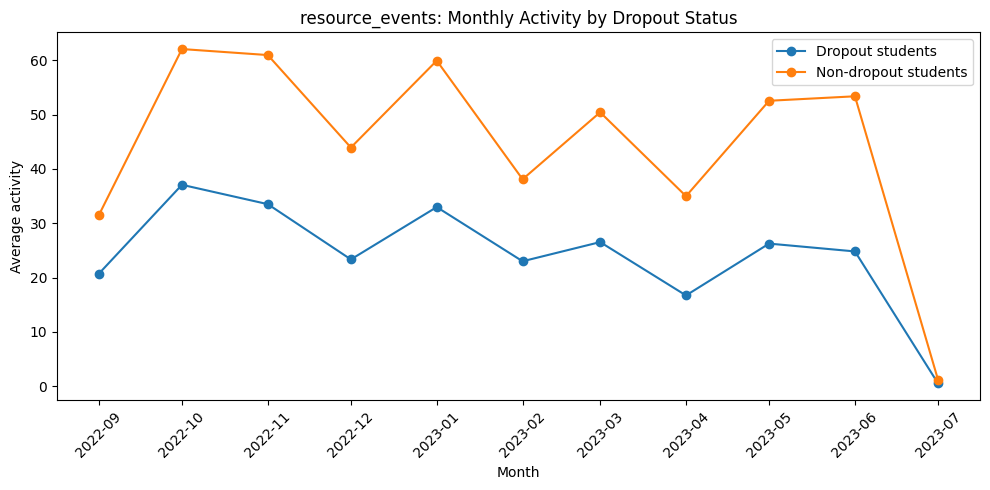

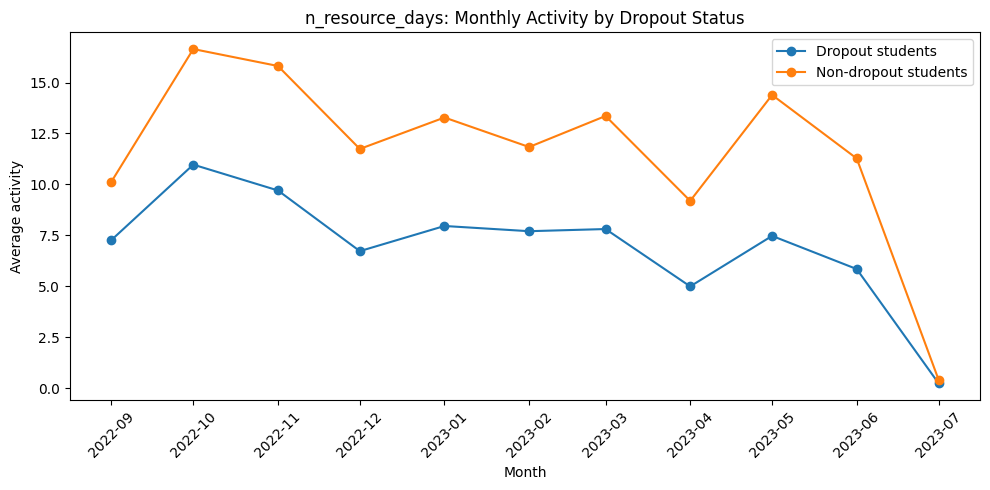

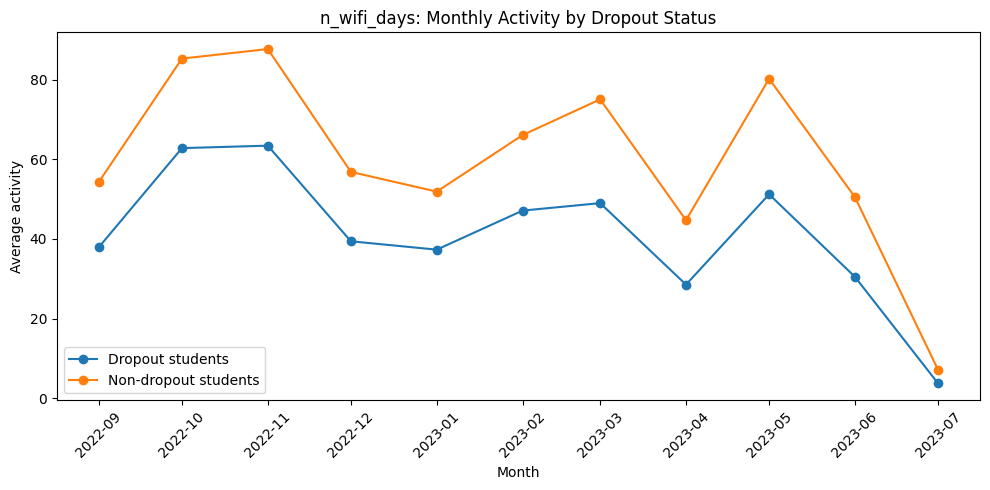

In [22]:
# ---------------------------------------------------------
# 10. Draw a separate monthly graph for every attribute
# ---------------------------------------------------------

for group_name in digital_groups:

    group_data = monthly_summary[
        monthly_summary["attribute"] == group_name
    ].copy()

    if group_data.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        group_data["date"],
        group_data["dropout_mean"],
        marker="o",
        label="Dropout students"
    )

    ax.plot(
        group_data["date"],
        group_data["non_dropout_mean"],
        marker="o",
        label="Non-dropout students"
    )

    ax.set_title(
        f"{group_name}: Monthly Activity by Dropout Status"
    )

    ax.set_xlabel("Month")

    ax.set_ylabel("Average activity")

    ax.legend()

    ax.tick_params(
        axis="x",
        rotation=45
    )

    plt.tight_layout()
    plt.show()


    #The similar trend indicates that both groups are affected by the same academic calendar.
     #However, non-dropout students consistently show higher platform activity, suggesting stronger and more sustained academic engagement.

Part 7: Correlation heatmap

month_label                 2022-09  2022-10  2022-11  2022-12  2023-01  \
attribute                                                                 
n_resource_days              -0.065   -0.081   -0.095   -0.098   -0.096   
n_wifi_days                  -0.076   -0.071   -0.075   -0.078   -0.062   
pft_assignment_submissions   -0.044   -0.034   -0.054   -0.066   -0.043   
pft_days_logged              -0.055   -0.076   -0.087   -0.093   -0.094   
pft_events                   -0.059   -0.063   -0.087   -0.089   -0.066   
pft_test_submissions         -0.031    0.038   -0.052   -0.050    0.055   
pft_total_minutes            -0.058   -0.078   -0.093   -0.094   -0.093   
pft_visits                   -0.056   -0.077   -0.089   -0.091   -0.091   
resource_events              -0.070   -0.086   -0.099   -0.095   -0.092   

month_label                 2023-02  2023-03  2023-04  2023-05  2023-06  \
attribute                                                                 
n_resource_days         

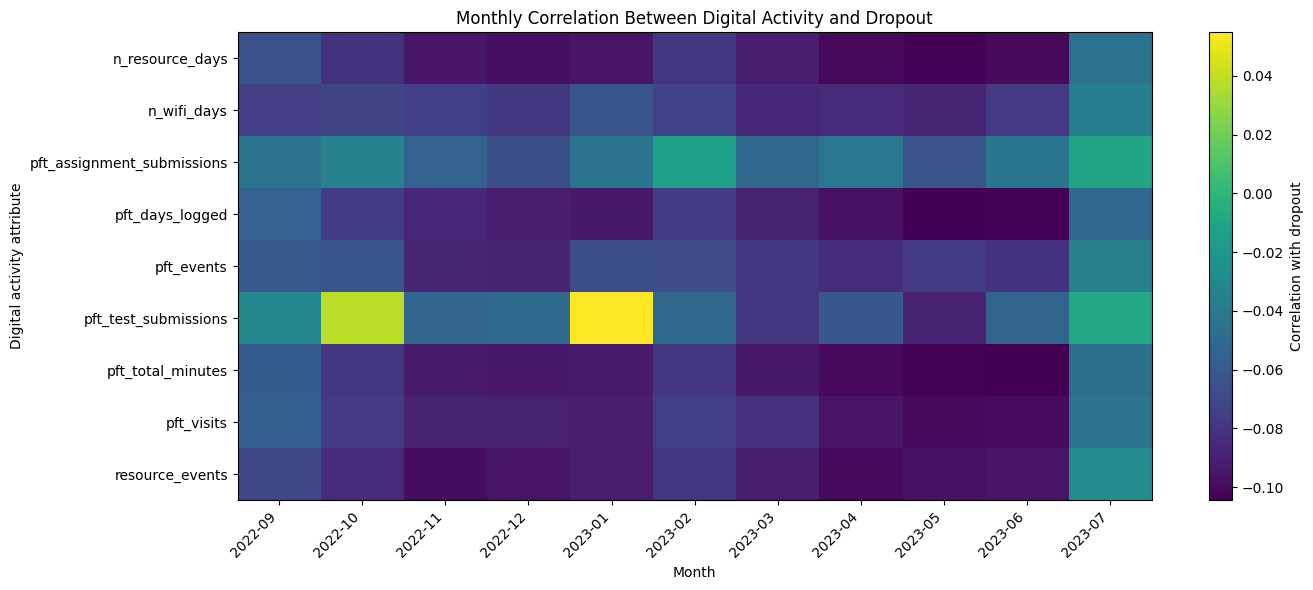

In [11]:
# ---------------------------------------------------------
# 11. Prepare monthly correlation heatmap
# ---------------------------------------------------------

heatmap_data = monthly_summary.copy()

heatmap_data["month_label"] = (
    heatmap_data["year"].astype(str)
    + "-"
    + heatmap_data["month"].astype(str).str.zfill(2)
)

correlation_matrix = heatmap_data.pivot(
    index="attribute",
    columns="month_label",
    values="correlation_with_dropout"
)

print(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    correlation_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_yticklabels(
    correlation_matrix.index
)

ax.set_title(
    "Monthly Correlation Between Digital Activity and Dropout"
)

ax.set_xlabel("Month")

ax.set_ylabel("Digital activity attribute")

fig.colorbar(
    image,
    ax=ax,
    label="Correlation with dropout"
)

plt.tight_layout()
plt.show()

Number of digital monthly columns: 99

Correlations with dropout:
pft_total_minutes_2023_6            -0.104
pft_days_logged_2023_5              -0.104
pft_total_minutes_2023_5            -0.104
pft_days_logged_2023_6              -0.103
n_resource_days_2023_5              -0.103
                                     ...  
pft_assignment_submissions_2023_2   -0.015
pft_assignment_submissions_2023_7   -0.011
pft_test_submissions_2023_7         -0.008
pft_test_submissions_2022_10         0.038
pft_test_submissions_2023_1          0.055
Length: 99, dtype: float64


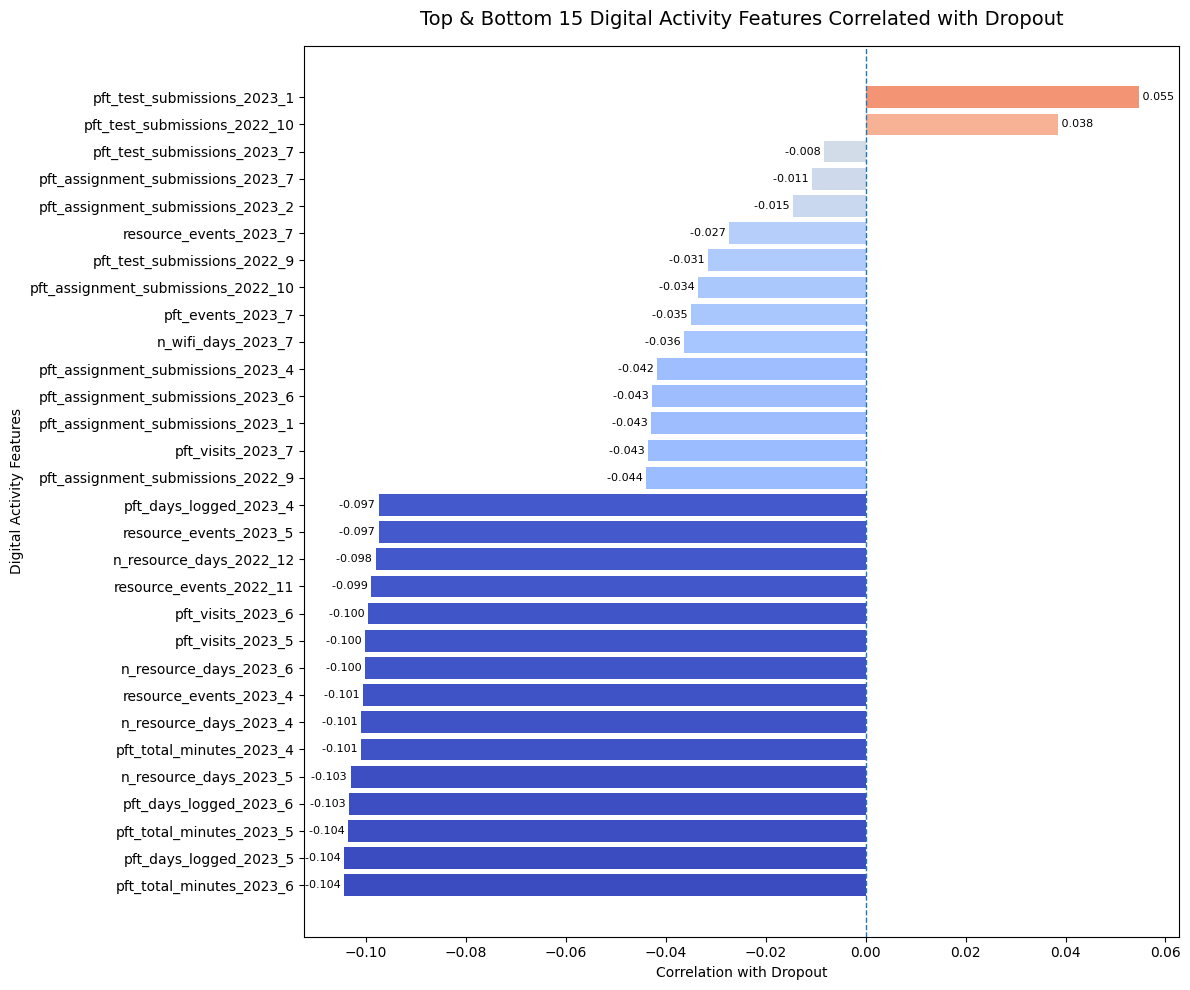

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# A = Dropout
# B = Non-Dropout
# ---------------------------------------------------------

if "dropout" not in df.columns:

    df["dropout"] = df["abandono_hash"].map({
        "A": 1,
        "B": 0
    })

df = df.dropna(subset=["dropout"]).copy()

# ---------------------------------------------------------
# ---------------------------------------------------------

digital_prefixes = [
    "pft_events",
    "pft_visits",
    "pft_days_logged",
    "pft_assignment_submissions",
    "pft_test_submissions",
    "pft_total_minutes",
    "resource_events",
    "n_resource_days",
    "n_wifi_days"
]

# ---------------------------------------------------------
# ---------------------------------------------------------

digital_columns = []

for column in df.columns:

    for prefix in digital_prefixes:

        if column.startswith(prefix + "_20"):
            digital_columns.append(column)
            break

print("Number of digital monthly columns:", len(digital_columns))

# ---------------------------------------------------------
# ---------------------------------------------------------

for column in digital_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# ---------------------------------------------------------
# ---------------------------------------------------------

correlations = (
    df[digital_columns]
    .corrwith(df["dropout"])
    .dropna()
    .sort_values()
)

print("\nCorrelations with dropout:")
print(correlations.round(3))

# ---------------------------------------------------------
# ---------------------------------------------------------

bottom_15 = correlations.head(15)
top_15 = correlations.tail(15)

selected_correlations = pd.concat([
    bottom_15,
    top_15
])

selected_correlations = selected_correlations[
    ~selected_correlations.index.duplicated()
]

selected_correlations = selected_correlations.sort_values()

# ---------------------------------------------------------
# ---------------------------------------------------------

max_absolute_correlation = max(
    abs(selected_correlations.min()),
    abs(selected_correlations.max())
)

if max_absolute_correlation == 0:
    max_absolute_correlation = 1

normalized_values = (
    selected_correlations + max_absolute_correlation
) / (
    2 * max_absolute_correlation
)

bar_colors = plt.cm.coolwarm(
    normalized_values
)

# ---------------------------------------------------------
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 10)
)

bars = ax.barh(
    selected_correlations.index,
    selected_correlations.values,
    color=bar_colors
)

ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Top & Bottom 15 Digital Activity Features "
    "Correlated with Dropout",
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "Correlation with Dropout"
)

ax.set_ylabel(
    "Digital Activity Features"
)

# ---------------------------------------------------------
# ---------------------------------------------------------

for bar, value in zip(
    bars,
    selected_correlations.values
):

    if value >= 0:

        ax.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {value:.3f}",
            va="center",
            ha="left",
            fontsize=8
        )

    else:

        ax.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f} ",
            va="center",
            ha="right",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Part 8: Export the results

In [15]:
# ---------------------------------------------------------
# 12. Save all results
# ---------------------------------------------------------

annual_summary.to_csv(
    "annual_digital_activity_analysis.csv",
    index=False
)

monthly_summary.to_csv(
    "monthly_digital_activity_analysis.csv",
    index=False
)

strongest_months.to_csv(
    "strongest_month_for_each_attribute.csv",
    index=False
)

print("Analysis files saved successfully.")

Analysis files saved successfully.


# Part 9: Dropout Prediction and Early-Warning Alerts

This section trains an early-warning model using the earliest LMS months, calculates a risk score, exports alert files, and can optionally send a consolidated email to the responsible student-support office.

**Important:** Review model performance and alert records manually before enabling email sending.

In [16]:

"""
Early-Warning Model for Student Dropout
=======================================

What this script does:
1. Loads students_2022.csv.
2. Converts abandono_hash: A = dropout, B = non-dropout.
3. Uses only the earliest LMS months to reduce future-data leakage.
4. Splits train/test data while keeping the same student in one split.
5. Trains a logistic-regression probability model.
6. Calculates a dropout-risk score for every record/student.
7. Creates LOW / MEDIUM / HIGH risk levels.
8. Saves alerts to CSV.
9. Optionally sends one consolidated email to the responsible office.

Important:
- An alert should trigger human review and student support, not an automatic
  administrative decision.
- Set EARLY_MONTHS_COUNT according to the actual intervention date.
"""

from __future__ import annotations

import json
import os
import re
import smtplib
from email.message import EmailMessage
from pathlib import Path
from typing import Iterable

import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# =========================================================
# 1. SETTINGS
# =========================================================

DATA_PATH = "students_2022.csv"

TARGET_SOURCE_COLUMN = "abandono_hash"
STUDENT_ID_COLUMN = "dni_hash"

# Number of earliest available months used for prediction.
# Example: 4 means that the model uses only the first four months found
# in the monthly LMS columns.
EARLY_MONTHS_COUNT = 4

TEST_SIZE = 0.20
RANDOM_STATE = 42

MEDIUM_RISK_THRESHOLD = 0.40
HIGH_RISK_THRESHOLD = 0.70

MODEL_OUTPUT = "dropout_early_warning_model.joblib"
METADATA_OUTPUT = "dropout_model_metadata.json"
PREDICTIONS_OUTPUT = "dropout_risk_predictions.csv"
STUDENT_ALERTS_OUTPUT = "student_dropout_alerts.csv"

# Keep False until SMTP variables are configured and the output is checked.
SEND_EMAILS = False


DIGITAL_PREFIXES = [
    "pft_events",
    "pft_visits",
    "pft_days_logged",
    "pft_assignment_submissions",
    "pft_test_submissions",
    "pft_total_minutes",
    "resource_events",
    "n_resource_days",
    "n_wifi_days",
]


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def extract_month(column_name: str) -> tuple[int, int] | None:
    """
    Extract (year, month) from a column ending with _YYYY_MM.
    Example: pft_events_2021_10 -> (2021, 10)
    """
    match = re.search(r"_(\d{4})_(\d{1,2})$", column_name)

    if match is None:
        return None

    year = int(match.group(1))
    month = int(match.group(2))

    if not 1 <= month <= 12:
        return None

    return year, month


def select_early_monthly_columns(
    columns: Iterable[str],
    prefixes: list[str],
    number_of_months: int,
) -> tuple[list[str], list[tuple[int, int]]]:
    """
    Select digital columns belonging to the earliest N calendar months.
    """
    column_months: dict[str, tuple[int, int]] = {}

    for column in columns:
        if not any(column.startswith(prefix + "_") for prefix in prefixes):
            continue

        month = extract_month(column)

        if month is not None:
            column_months[column] = month

    available_months = sorted(set(column_months.values()))

    if not available_months:
        raise ValueError(
            "No monthly digital columns ending with _YYYY_MM were found."
        )

    selected_months = available_months[:number_of_months]

    selected_columns = sorted(
        [
            column
            for column, month in column_months.items()
            if month in selected_months
        ],
        key=lambda column: (
            column.rsplit("_", 2)[0],
            column_months[column],
        ),
    )

    return selected_columns, selected_months


def make_early_warning_features(
    data: pd.DataFrame,
    selected_months: list[tuple[int, int]],
    prefixes: list[str],
) -> pd.DataFrame:
    """
    Build model features from selected early monthly activity.

    It keeps the monthly values and creates:
    - total activity
    - monthly mean
    - number of active months
    - number of zero-activity months
    - last-minus-first activity trend
    """
    feature_data = pd.DataFrame(index=data.index)

    for prefix in prefixes:
        prefix_columns = []

        for year, month in selected_months:
            column = f"{prefix}_{year}_{month}"

            if column in data.columns:
                prefix_columns.append(column)

        if not prefix_columns:
            continue

        numeric_block = data[prefix_columns].apply(
            pd.to_numeric,
            errors="coerce",
        )

        # Keep original early monthly columns.
        for column in prefix_columns:
            feature_data[column] = numeric_block[column]

        feature_data[f"{prefix}_early_total"] = numeric_block.sum(
            axis=1,
            min_count=1,
        )

        feature_data[f"{prefix}_early_mean"] = numeric_block.mean(axis=1)

        feature_data[f"{prefix}_early_active_months"] = (
            numeric_block.fillna(0) > 0
        ).sum(axis=1)

        feature_data[f"{prefix}_early_zero_months"] = (
            numeric_block.fillna(0) == 0
        ).sum(axis=1)

        if len(prefix_columns) >= 2:
            feature_data[f"{prefix}_early_trend"] = (
                numeric_block[prefix_columns[-1]]
                - numeric_block[prefix_columns[0]]
            )
        else:
            feature_data[f"{prefix}_early_trend"] = 0.0

    if feature_data.empty:
        raise ValueError("No usable early-warning features were created.")

    feature_data = feature_data.replace([np.inf, -np.inf], np.nan)

    return feature_data


def assign_risk_level(probability: float) -> str:
    """Convert risk probability into LOW, MEDIUM, or HIGH."""
    if probability >= HIGH_RISK_THRESHOLD:
        return "HIGH"
    if probability >= MEDIUM_RISK_THRESHOLD:
        return "MEDIUM"
    return "LOW"


def safely_compute_auc(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> tuple[float, float]:
    """Calculate ROC-AUC and PR-AUC when both target classes exist."""
    if pd.Series(y_true).nunique() < 2:
        return float("nan"), float("nan")

    return (
        roc_auc_score(y_true, probabilities),
        average_precision_score(y_true, probabilities),
    )


def create_email_body(high_risk_alerts: pd.DataFrame) -> str:
    """Create one consolidated support-office alert."""
    if high_risk_alerts.empty:
        return "No students crossed the high-risk threshold."

    display_columns = [
        column
        for column in [
            STUDENT_ID_COLUMN,
            "dropout_risk_probability",
            "dropout_risk_percent",
            "risk_level",
        ]
        if column in high_risk_alerts.columns
    ]

    table_text = high_risk_alerts[display_columns].to_string(index=False)

    return f"""Student Dropout Early-Warning Alert

The model identified {len(high_risk_alerts)} student(s) whose estimated
dropout-risk score is at or above {HIGH_RISK_THRESHOLD:.0%}.

Please review these cases manually and consider supportive contact.
The score must not be used as the sole basis for an administrative decision.

{table_text}
"""


def send_email_alert(subject: str, body: str) -> None:
    """
    Send an email using environment variables.

    Required environment variables:
    SMTP_HOST
    SMTP_PORT
    SMTP_USERNAME
    SMTP_PASSWORD
    ALERT_SENDER
    ALERT_RECIPIENT

    Optional:
    SMTP_USE_TLS=true
    """
    required_variables = [
        "SMTP_HOST",
        "SMTP_PORT",
        "SMTP_USERNAME",
        "SMTP_PASSWORD",
        "ALERT_SENDER",
        "ALERT_RECIPIENT",
    ]

    missing_variables = [
        name for name in required_variables if not os.getenv(name)
    ]

    if missing_variables:
        raise RuntimeError(
            "Missing email environment variables: "
            + ", ".join(missing_variables)
        )

    smtp_host = os.environ["SMTP_HOST"]
    smtp_port = int(os.environ["SMTP_PORT"])
    smtp_username = os.environ["SMTP_USERNAME"]
    smtp_password = os.environ["SMTP_PASSWORD"]
    sender = os.environ["ALERT_SENDER"]
    recipient = os.environ["ALERT_RECIPIENT"]

    use_tls = os.getenv("SMTP_USE_TLS", "true").lower() == "true"

    message = EmailMessage()
    message["Subject"] = subject
    message["From"] = sender
    message["To"] = recipient
    message.set_content(body)

    with smtplib.SMTP(smtp_host, smtp_port, timeout=30) as server:
        if use_tls:
            server.starttls()

        server.login(smtp_username, smtp_password)
        server.send_message(message)


# =========================================================
# 3. LOAD AND PREPARE DATA
# =========================================================

data_path = Path(DATA_PATH)

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_path.resolve()}"
    )

df = pd.read_csv(data_path, low_memory=False)

required_columns = {TARGET_SOURCE_COLUMN}

missing_required = required_columns.difference(df.columns)

if missing_required:
    raise KeyError(
        "Missing required columns: "
        + ", ".join(sorted(missing_required))
    )

# Keep only valid labelled records.
df = df[df[TARGET_SOURCE_COLUMN].isin(["A", "B"])].copy()

# A = dropout, B = non-dropout.
df["dropout"] = df[TARGET_SOURCE_COLUMN].map(
    {"A": 1, "B": 0}
).astype(int)

selected_columns, selected_months = select_early_monthly_columns(
    columns=df.columns,
    prefixes=DIGITAL_PREFIXES,
    number_of_months=EARLY_MONTHS_COUNT,
)

X = make_early_warning_features(
    data=df,
    selected_months=selected_months,
    prefixes=DIGITAL_PREFIXES,
)

y = df["dropout"]

print("Dataset rows:", len(df))
print("Dropout rate:", f"{y.mean():.2%}")
print("Prediction months:", selected_months)
print("Number of model features:", X.shape[1])


# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

if STUDENT_ID_COLUMN in df.columns:
    groups = df[STUDENT_ID_COLUMN].astype(str)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    train_positions, test_positions = next(
        splitter.split(X, y, groups=groups)
    )

else:
    all_positions = np.arange(len(df))

    train_positions, test_positions = train_test_split(
        all_positions,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

X_train = X.iloc[train_positions]
X_test = X.iloc[test_positions]

y_train = y.iloc[train_positions]
y_test = y.iloc[test_positions]


# =========================================================
# 5. MODEL
# =========================================================

model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)


# =========================================================
# 6. TEST PERFORMANCE
# =========================================================

test_probabilities = model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_probabilities >= HIGH_RISK_THRESHOLD
).astype(int)

roc_auc, pr_auc = safely_compute_auc(
    y_test,
    test_probabilities,
)

print("\n================ MODEL EVALUATION ================")
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print(
    "\nClassification report at high-risk threshold "
    f"{HIGH_RISK_THRESHOLD:.0%}:"
)

print(
    classification_report(
        y_test,
        test_predictions,
        labels=[0, 1],
        target_names=["Non-dropout", "Dropout"],
        zero_division=0,
    )
)

print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions, labels=[0, 1]))


# =========================================================
# 7. FIT FINAL MODEL AND SCORE ALL CURRENT RECORDS
# =========================================================

# After evaluation, refit on all labelled historical records.
model.fit(X, y)

all_probabilities = model.predict_proba(X)[:, 1]

risk_results = pd.DataFrame(index=df.index)

if STUDENT_ID_COLUMN in df.columns:
    risk_results[STUDENT_ID_COLUMN] = df[STUDENT_ID_COLUMN].astype(str)
else:
    risk_results["record_id"] = df.index.astype(str)

risk_results["actual_dropout"] = y
risk_results["dropout_risk_probability"] = all_probabilities
risk_results["dropout_risk_percent"] = (
    risk_results["dropout_risk_probability"] * 100
).round(2)

risk_results["risk_level"] = risk_results[
    "dropout_risk_probability"
].apply(assign_risk_level)

risk_results.to_csv(PREDICTIONS_OUTPUT, index=False)


# =========================================================
# 8. CREATE ONE ALERT PER STUDENT
# =========================================================

if STUDENT_ID_COLUMN in risk_results.columns:
    # When a student has several course/subject rows, use the highest risk
    # as the student's alert score.
    student_alerts = (
        risk_results
        .groupby(STUDENT_ID_COLUMN, as_index=False)
        .agg(
            dropout_risk_probability=(
                "dropout_risk_probability",
                "max",
            ),
            dropout_risk_percent=(
                "dropout_risk_percent",
                "max",
            ),
            risk_level=("risk_level", lambda values: (
                "HIGH" if "HIGH" in set(values)
                else "MEDIUM" if "MEDIUM" in set(values)
                else "LOW"
            )),
        )
    )
else:
    student_alerts = risk_results.copy()

student_alerts = student_alerts.sort_values(
    "dropout_risk_probability",
    ascending=False,
)

student_alerts.to_csv(STUDENT_ALERTS_OUTPUT, index=False)

high_risk_alerts = student_alerts[
    student_alerts["dropout_risk_probability"]
    >= HIGH_RISK_THRESHOLD
].copy()

print("\n================ ALERT SUMMARY ================")
print("High-risk students:", len(high_risk_alerts))
print("Medium-risk students:", int(
    (
        (student_alerts["dropout_risk_probability"]
         >= MEDIUM_RISK_THRESHOLD)
        &
        (student_alerts["dropout_risk_probability"]
         < HIGH_RISK_THRESHOLD)
    ).sum()
))
print("Saved:", PREDICTIONS_OUTPUT)
print("Saved:", STUDENT_ALERTS_OUTPUT)


# =========================================================
# 9. SAVE MODEL AND METADATA
# =========================================================

joblib.dump(
    {
        "model": model,
        "feature_columns": list(X.columns),
        "selected_months": selected_months,
        "digital_prefixes": DIGITAL_PREFIXES,
        "medium_risk_threshold": MEDIUM_RISK_THRESHOLD,
        "high_risk_threshold": HIGH_RISK_THRESHOLD,
    },
    MODEL_OUTPUT,
)

metadata = {
    "target_definition": {
        "A": 1,
        "B": 0,
    },
    "student_id_column": (
        STUDENT_ID_COLUMN
        if STUDENT_ID_COLUMN in df.columns
        else None
    ),
    "selected_months": selected_months,
    "number_of_features": X.shape[1],
    "test_roc_auc": (
        None if np.isnan(roc_auc) else round(float(roc_auc), 6)
    ),
    "test_pr_auc": (
        None if np.isnan(pr_auc) else round(float(pr_auc), 6)
    ),
    "medium_risk_threshold": MEDIUM_RISK_THRESHOLD,
    "high_risk_threshold": HIGH_RISK_THRESHOLD,
}

with open(METADATA_OUTPUT, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved:", MODEL_OUTPUT)
print("Saved:", METADATA_OUTPUT)


# =========================================================
# 10. OPTIONAL EMAIL
# =========================================================

if SEND_EMAILS and not high_risk_alerts.empty:
    email_body = create_email_body(high_risk_alerts)

    send_email_alert(
        subject=(
            f"Dropout Early-Warning Alert: "
            f"{len(high_risk_alerts)} high-risk student(s)"
        ),
        body=email_body,
    )

    print("Email alert sent successfully.")

elif SEND_EMAILS:
    print("No email sent because no student crossed the threshold.")

else:
    print(
        "Email sending is disabled. Review the CSV alerts first, "
        "then set SEND_EMAILS = True after configuring SMTP variables."
    )


Dataset rows: 20427
Dropout rate: 7.31%
Prediction months: [(2022, 9), (2022, 10), (2022, 11), (2022, 12)]
Number of model features: 81

================ MODEL EVALUATION ================
ROC-AUC: 0.6693
PR-AUC: 0.1389

Classification report at high-risk threshold 70%:
              precision    recall  f1-score   support

 Non-dropout       0.94      0.98      0.96      3813
     Dropout       0.25      0.09      0.13       273

    accuracy                           0.92      4086
   macro avg       0.60      0.53      0.54      4086
weighted avg       0.89      0.92      0.90      4086

Confusion matrix:
[[3742   71]
 [ 249   24]]

================ ALERT SUMMARY ================
High-risk students: 413
Medium-risk students: 13231
Saved: dropout_risk_predictions.csv
Saved: student_dropout_alerts.csv
Saved: dropout_early_warning_model.joblib
Saved: dropout_model_metadata.json
Email sending is disabled. Review the CSV alerts first, then set SEND_EMAILS = True after configuring SMTP var